In [1]:
# fixed_softmax_gaussian_demo.py
# ---------------------------------------------------------
# 1D fixed-logit softmax-Gaussian interpolant in JAX/Flax-NNX
# - Nodes: uniform or Chebyshev-Lobatto
# - Exact Gaussian logits: w_j = x_j / ε^2, b_j = -||x_j||^2/(2ε^2) + log a_j
# - Output: p_ε(x) = sum_j softmax(w_j x + b_j) * y_j
#
# Visualizes:
#   (1) α_i(x_i) vs ε/δ (median & minimum across nodes)
#   (2) Global error (RMSE & Linf on a dense grid) vs ε/δ
#
# Notes:
# - This is a Nadaraya–Watson–style *normalized* smoother; it is
#   exact at nodes as ε → 0 (weights become one-hot) but does not
#   reproduce the barycentric *rational* curve off-nodes.
# - jax.nn.softmax is numerically stable (log-sum-exp).
# ---------------------------------------------------------

from __future__ import annotations
import math
import jax
import jax.numpy as jnp
from flax import nnx
import numpy as np
import matplotlib.pyplot as plt
import optax
from tqdm import tqdm
from jaxpi.ssbroyden_optax import scale_by_ssbroyden_wolfe_oracle

# ----- FP64 everywhere
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64



In [ ]:
# =========================
# Nodes & utilities
# =========================

def cheb_lobatto_nodes(M: int) -> jnp.ndarray:
    """M Chebyshev-Lobatto nodes on [-1,1], j=0..M-1."""
    j = jnp.arange(M, dtype=DTYPE)
    return jnp.cos(jnp.pi * j / (M - 1))

def cheb2_weights(M: int) -> jnp.ndarray:
    # M >= 2
    j = jnp.arange(M, dtype=DTYPE)
    w = (-1.0) ** j
    w = w.at[0].mul(0.5)
    w = w.at[-1].mul(0.5)      # keeps the correct sign automatically
    return w

def cheb_lobatto_weight_signs(M: int) -> jnp.ndarray:
    # w_j ∝ (-1)^j with endpoints |w_0|=|w_{M-1}|=1/2; signs are just (-1)^j.
    j = jnp.arange(M, dtype=jnp.int32)
    return jnp.where((j & 1) == 0, DTYPE(1.0), DTYPE(-1.0))

def uniform_nodes(M: int) -> jnp.ndarray:
    return jnp.linspace(-1.0, 1.0, M, dtype=DTYPE)

def min_separation(xs: jnp.ndarray) -> DTYPE:
    """δ = min_{i≠j} |x_i - x_j|."""
    xs = xs.reshape(-1, 1)
    D = jnp.abs(xs - xs.T)
    D = D + jnp.eye(xs.shape[0], dtype=DTYPE) * 1e9
    return jnp.min(D)


In [3]:
# =========================
# Exact Gaussian logits
# =========================
def fixed_gaussian_logits(xs: jnp.ndarray, epsilon: DTYPE, a: jnp.ndarray | None = None):
    """
    Return W, b such that logits_j(x) = W[j] * x + b[j]
    corresponds to log a_j - (x - x_j)^2 / (2 ε^2), *up to*
    the -x^2/(2 ε^2) constant (cancels in softmax).

    The a's are optional, and correspond to the chebyshev weights in the second barycentric formula. 
    """
    xs = jnp.asarray(xs, dtype=DTYPE)
    inv_var = DTYPE(1.0) / (epsilon ** 2)
    W = xs * inv_var                                    # shape [M]
    b = -0.5 * (xs ** 2) * inv_var                      # shape [M]
    if a is not None:
        a = jnp.asarray(a, dtype=DTYPE)
        b = b + jnp.log(jnp.abs(a))
    return W, b

In [4]:

# =========================
# Fixed-logit softmax-Gaussian "MLP"
# =========================
class FixedGaussianSoftmax(nnx.Module):
    W: nnx.Param
    b: nnx.Param
    y: nnx.Param

    def __init__(self, xs: jnp.ndarray, ys: jnp.ndarray, epsilon: DTYPE,
                 a: jnp.ndarray | None = None, *, rngs: nnx.Rngs | None = None):
        W, b = fixed_gaussian_logits(xs, epsilon, a)
        self.W = nnx.Param(W)             # [M]
        self.b = nnx.Param(b)             # [M]
        self.y = nnx.Param(jnp.asarray(ys, dtype=DTYPE))  # [M]

    def __call__(self, x: jnp.ndarray):
        """
        x: shape [...] (scalar or batch)
        Returns:
          y_hat: shape [...]
          alpha: shape [..., M]  (softmax weights)
        """
        # Broadcast to [..., M]
        logits = self.W[None, ...] * x[..., None] + self.b[None, ...]
        alpha = jax.nn.softmax(logits, axis=-1)
        y_hat = jnp.einsum('...m,m->...', alpha, self.y)
        return y_hat


In [5]:
class SigmaGate(nnx.Module):
    """Fixed-weight MLP that outputs σ_j(x) ≈ sign(w_j) * sign(x - x_j) for all j."""
    W: nnx.Param     # shape [M], all entries = beta
    b: nnx.Param     # shape [M], entries = -beta * x_j
    s_w: nnx.Param   # shape [M], entries = sign(w_j)
    beta: DTYPE
    eps_s: DTYPE
    mode: str

    def __init__(self,
                 x_nodes: jnp.ndarray,            # [M]
                 w_signs: jnp.ndarray,            # [M], = sign(w_j)
                 beta: float = 50.0,              # sharpness of the sign
                 eps_s: float = 1e-6,             # only used by 'rational'
                 mode: str = "rational",          # 'tanh' | 'logistic' | 'rational'
                 *, rngs: nnx.Rngs | None = None):
        x_nodes = jnp.asarray(x_nodes, dtype=DTYPE)
        w_signs = jnp.asarray(w_signs, dtype=DTYPE)
        self.beta = DTYPE(beta)
        self.eps_s = DTYPE(eps_s)
        self.mode = mode
        self.W = nnx.Param(jnp.full_like(x_nodes, self.beta))         # W_j = beta
        self.b = nnx.Param(-self.beta * x_nodes)                       # b_j = -beta * x_j
        self.s_w = nnx.Param(w_signs)                                  # sign(w_j)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        """
        x: [...], scalar or batch
        returns: sigma [..., M]
        """
        z = self.W[None, ...] * x[..., None] + self.b[None, ...]       # z_j(x)=βx-βx_j
        if self.mode == "tanh":
            s = jnp.tanh(z)
        elif self.mode == "logistic":
            s = 2.0 * jax.nn.sigmoid(z) - 1.0
        elif self.mode == "rational":
            # recover (x - x_j) = z / beta, then apply smooth sign
            dz = z / self.beta
            s = dz / jnp.sqrt(dz * dz + self.eps_s * self.eps_s)
        else:
            raise ValueError(f"Unknown mode {self.mode}")
        return self.s_w[None, ...] * s  # multiply by constant sign(w_j)


In [6]:
def signed_normalize(
    logits: jnp.ndarray,
    signs: jnp.ndarray,
    values: jnp.ndarray,
    axis: int = -1,
    return_alpha: bool = False,
):
    """
    Compute the signed, softmax-like normalized ratio:

        y_hat = [ Σ_j signs_j * exp(logits_j) * values_j ]  /
                [ Σ_j signs_j * exp(logits_j) ]

    using a shared max-shift for numerical stability.
    Optionally return the signed "softmax" weights α as well.

    Shapes:
      logits: [..., M]
      signs:  [..., M]    (entries in [-1, 1]; e.g., SigmaGate output)
      values: [..., M]    (e.g., y_j broadcast to match logits)
      axis:   reduction axis (defaults to last)

    Returns:
      y_hat:  logits shape with `axis` removed
      alpha:  (optional) [..., M]
    """
    logits = jnp.asarray(logits, dtype=DTYPE)
    signs  = jnp.asarray(signs,  dtype=DTYPE)
    values = jnp.asarray(values, dtype=DTYPE)

    # Shared stabilization (prevents overflow): subtract row-wise max
    m  = jnp.max(logits, axis=axis, keepdims=True)
    u  = logits - m
    eu = jnp.exp(u)  # in (0, 1] elementwise

    # Denominator: Σ s_j e^{u_j} = (Σ pos) - (Σ neg)
    s_pos = jnp.maximum(signs,  0.0)
    s_neg = jnp.maximum(-signs, 0.0)
    denom_pos = jnp.sum(s_pos * eu, axis=axis, keepdims=True)
    denom_neg = jnp.sum(s_neg * eu, axis=axis, keepdims=True)
    denom = denom_pos - denom_neg

    # Numerator: Σ (s_j * v_j) e^{u_j} = (Σ pos) - (Σ neg)
    t = signs * values
    t_pos = jnp.maximum(t,  0.0)
    t_neg = jnp.maximum(-t, 0.0)
    numer_pos = jnp.sum(t_pos * eu, axis=axis, keepdims=True)
    numer_neg = jnp.sum(t_neg * eu, axis=axis, keepdims=True)
    numer = numer_pos - numer_neg

    # Final ratio (remove the reduced dimension)
    y_hat = (numer / denom)
    y_hat = jnp.squeeze(y_hat, axis=axis)

    if return_alpha:
        alpha = (signs * eu) / denom  # [..., M]
        return y_hat, alpha
    else:
        return y_hat

def logdiffexp(a, b):
    # returns log(exp(a) - exp(b)) for a >= b, stably
    return a + jnp.log1p(-jnp.exp(b - a))

def signed_lse(u, weights, axis=-1):
    # u: logits shifted by max (so safe), weights >= 0 (magnitudes already applied)
    # returns (sign, log_abs_sum)
    lse = jax.nn.logsumexp
    # split by sign outside, so here 'weights' is either s_pos*eu or s_neg*eu
    return lse(jnp.log(weights) + 0.0, axis=axis)  # weights are positive

def signed_normalize_stable(logits, signs, values, axis=-1, return_alpha=False):
    m = jnp.max(logits, axis=axis, keepdims=True)
    u = logits - m
    eu = jnp.exp(u)

    s_pos = jnp.maximum(signs,  0.0)
    s_neg = jnp.maximum(-signs, 0.0)

    # Denominator logs
    Lp = jax.nn.logsumexp(jnp.log(s_pos + 1e-300) + u, axis=axis, keepdims=True)
    Ln = jax.nn.logsumexp(jnp.log(s_neg + 1e-300) + u, axis=axis, keepdims=True)
    # ensure a >= b for logdiffexp
    a, b = jnp.maximum(Lp, Ln), jnp.minimum(Lp, Ln)
    denom_sign = jnp.where(Lp >= Ln, 1.0, -1.0)
    log_denom = logdiffexp(a, b)

    # Numerator logs (use t = signs*values)
    t = signs * values
    t_pos = jnp.maximum(t,  0.0)
    t_neg = jnp.maximum(-t, 0.0)
    Ap = jax.nn.logsumexp(jnp.log(t_pos + 1e-300) + u, axis=axis, keepdims=True)
    An = jax.nn.logsumexp(jnp.log(t_neg + 1e-300) + u, axis=axis, keepdims=True)
    a, b = jnp.maximum(Ap, An), jnp.minimum(Ap, An)
    numer_sign = jnp.where(Ap >= An, 1.0, -1.0)
    log_numer = logdiffexp(a, b)

    # Final ratio in linear domain; exp(m) cancels
    y_hat = (numer_sign * jnp.exp(log_numer)) / (denom_sign * jnp.exp(log_denom))
    y_hat = jnp.squeeze(y_hat, axis=axis)

    if return_alpha:
        # alpha is not a probability when signs are present; only use diagnostically
        alpha = (signs * eu) / (denom_sign * jnp.exp(log_denom))  # [..., M]
        return y_hat, alpha
    else:
        return y_hat



class SignedGaussianSoftmax(nnx.Module):
    def __init__(self, fixedgaussian: FixedGaussianSoftmax,
                 sigma_gate: SigmaGate | None = None,
                 *, rngs: nnx.Rngs | None = None):
        self.fixedgaussian = fixedgaussian
        self.sigma_gate = sigma_gate

    def __call__(self, x: jnp.ndarray):
        """
        x: shape [...] (scalar or batch)

        Returns:
          y_hat: shape [...]          (ratio of signed sums)
          alpha: shape [..., M]       (optional diagnostic weights)
        """
        logits = self.fixedgaussian.W[None, ...] * x[..., None] + self.fixedgaussian.b[None, ...]
        signs  = self.sigma_gate(x) if self.sigma_gate is not None else jnp.ones_like(logits, dtype=DTYPE)

        # Use shared-shift signed normalization to get y_hat directly.
        y_hat, alpha = signed_normalize_stable(
            logits,
            signs,
            values=self.fixedgaussian.y,   # broadcasted y_j
            axis=-1,
            return_alpha=True,
        )
        return y_hat, alpha


In [7]:
# =========================
# Target function & metrics
# =========================
def f_sin(x: jnp.ndarray, k: int) -> jnp.ndarray:
    return jnp.sin(2.0 * jnp.pi * DTYPE(k) * x)


def error_metrics(y_hat: jnp.ndarray, y_true: jnp.ndarray):
    err = jnp.abs(y_hat - y_true)
    rmse = jnp.sqrt(jnp.mean((y_hat - y_true) ** 2))
    linf = jnp.max(err)
    return rmse, linf

In [8]:
# =========================
# Driver: sweep epsilon (simplified - no alpha tracking)
# =========================
def run_demo(
    M: int = 33,
    k: int = 3,
    node_type: str = "cheb",  # "cheb" or "uniform"
    c_min: float = 0.0001,
    c_max: float = 20.0,
    n_c: int = 16,
    n_eval: int = 4097,
    seed: int = 0,
    sigma_gate: bool = False,
    sigma_beta: float = 50.0,
    sigma_eps_s: float = 1e-6,
    sigma_mode: str = "rational",  # 'tanh' | 'logistic' | 'rational'
):
    key = jax.random.PRNGKey(seed)

    # Nodes
    xs = cheb_lobatto_nodes(M) if node_type == "cheb" else uniform_nodes(M)
    ys = f_sin(xs, k)
    cheb_weights = cheb2_weights(M) if node_type == "cheb" else None
    delta = min_separation(xs)

    # Evaluation grid
    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE)
    y_eval = f_sin(x_eval, k)

    # ε sweep (as multiples of δ)
    cs = jnp.geomspace(DTYPE(c_min), DTYPE(c_max), n_c)
    eps_list = cs * delta
    print("Running sweep with ε in [%.3g, %.3g], δ=%.3g" % (eps_list[0], eps_list[-1], delta))

    rmse_list = []
    linf_list = []

    # Simplified build_and_eval functions (no alpha tracking)
    if sigma_gate:
        def build_and_eval(eps):
            w_signs = cheb_lobatto_weight_signs(M) if node_type == "cheb" else jnp.ones(M, dtype=DTYPE)
            sigma_mdl = SigmaGate(xs, w_signs, beta=sigma_beta, eps_s=sigma_eps_s, mode=sigma_mode)
            gaussian_mdl = FixedGaussianSoftmax(xs, ys, eps, a=cheb_weights)
            mdl = SignedGaussianSoftmax(gaussian_mdl, sigma_mdl)
            y_hat, _ = mdl(x_eval)
            rmse, linf = error_metrics(y_hat, y_eval)
            return rmse, linf
    else: 
        def build_and_eval(eps):
            mdl = FixedGaussianSoftmax(xs, ys, eps, a=cheb_weights)
            y_hat = mdl(x_eval)
            rmse, linf = error_metrics(y_hat, y_eval)
            return rmse, linf

    build_and_eval_jit = jax.jit(build_and_eval)

    for eps in eps_list:
        rmse, linf = build_and_eval_jit(eps)
        rmse_list.append(rmse)
        linf_list.append(linf)

    rmse_list = jnp.asarray(rmse_list)
    linf_list = jnp.asarray(linf_list)

    # ----------------- Plot only global errors -----------------
    plt.figure(figsize=(8, 5))
    plt.semilogx(cs, rmse_list, marker='o', label='RMSE', linewidth=2)
    plt.semilogx(cs, linf_list, marker='s', label=r'$L_\infty$', linewidth=2)
    plt.xlabel(r'$\varepsilon / \delta$', fontsize=12)
    plt.ylabel('Error', fontsize=12)
    plt.title(f'Global error for f(x)=sin(2π{k}x) (M={M}, nodes={node_type})', fontsize=14)
    plt.grid(True, which='both', ls=':', alpha=0.7)
    plt.legend(loc='upper right', fontsize=12)
    plt.tight_layout()

    # Show one "profile" example at a chosen ε
    eps_show = float((0.5 * (c_min + c_max)) * float(delta))

    if sigma_gate:
        w_signs = cheb_lobatto_weight_signs(M) if node_type == "cheb" else jnp.ones(M, dtype=DTYPE)
        sigma_mdl = SigmaGate(xs, w_signs, beta=sigma_beta, eps_s=sigma_eps_s, mode=sigma_mode)
        gaussian_mdl = FixedGaussianSoftmax(xs, ys, DTYPE(eps_show), a=cheb_weights)
        mdl_show = SignedGaussianSoftmax(gaussian_mdl, sigma_mdl)
        y_hat_show, _ = mdl_show(x_eval)
    else:
        mdl_show = FixedGaussianSoftmax(xs, ys, DTYPE(eps_show), a=cheb_weights)
        y_hat_show = mdl_show(x_eval)

    plt.figure(figsize=(8, 5))
    plt.plot(x_eval, y_eval, lw=2, label='Target sin(2πkx)', color='blue')
    plt.plot(x_eval, np.array(y_hat_show), lw=1.5, label=f'Softmax-Gaussian (ε≈{eps_show/delta:.2f} δ)', color='red', alpha=0.8)
    plt.plot(xs, ys, 'ko', ms=5, label='Nodes', alpha=0.7)
    plt.ylim(-1.2, 1.2)
    plt.title(f'Approximation at ε/δ ≈ {eps_show/delta:.2f} (k={k}, M={M}, {node_type})', fontsize=14)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, ls=':', alpha=0.7)
    plt.tight_layout()

    plt.show()

    # Return results for further analysis
    return {
        'cs': cs,
        'eps_list': eps_list,
        'rmse_list': rmse_list,
        'linf_list': linf_list,
        'delta': delta
    }

In [9]:
xs = cheb_lobatto_nodes(33)
ys = f_sin(xs, k=5)
a0 = jnp.ones_like(xs)
w_signs = jnp.sign(ys)

Running sweep with ε in [0.000482, 0.0963], δ=0.00482


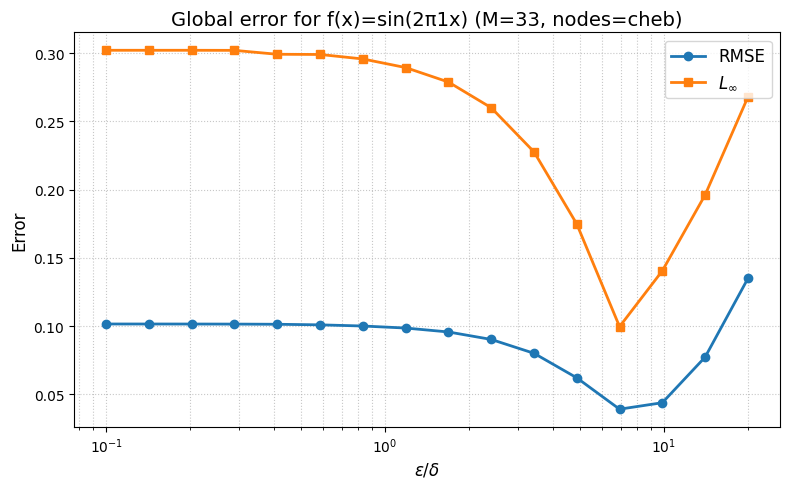

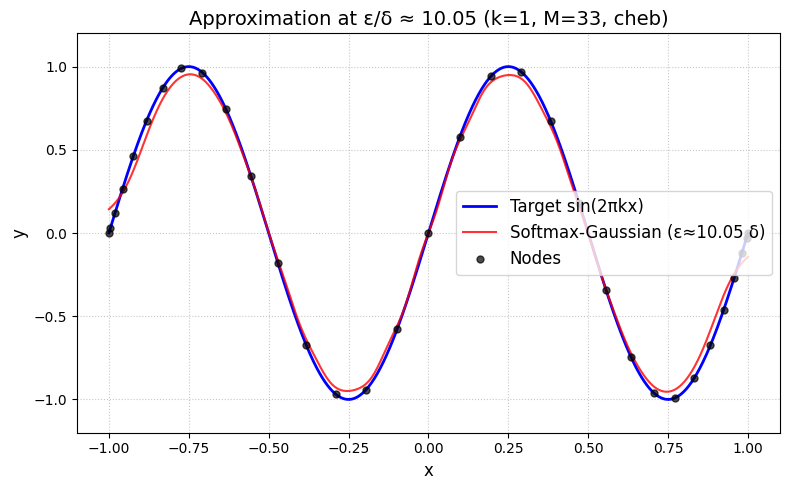

{'cs': Array([ 0.1       ,  0.1423646 ,  0.20267678,  0.28853998,  0.41077878,
         0.58480355,  0.83255321,  1.18526101,  1.68739205,  2.40224887,
         3.41995189,  4.86880069,  6.93144843,  9.86792855, 14.0484366 ,
        20.        ], dtype=float64),
 'eps_list': Array([0.00048153, 0.00068552, 0.00097594, 0.0013894 , 0.00197801,
        0.00281599, 0.00400897, 0.00570736, 0.00812525, 0.01156748,
        0.016468  , 0.02344461, 0.03337682, 0.04751677, 0.06764706,
        0.09630547], dtype=float64),
 'rmse_list': Array([0.10155767, 0.10154312, 0.10152528, 0.10148112, 0.10135521,
        0.10092985, 0.10008255, 0.09859252, 0.09572193, 0.09024967,
        0.08010063, 0.06214948, 0.0391726 , 0.04391109, 0.07730648,
        0.13488691], dtype=float64),
 'linf_list': Array([0.30200595, 0.30200595, 0.30200594, 0.30194533, 0.2990798 ,
        0.29893132, 0.29565336, 0.28934545, 0.27875754, 0.2599371 ,
        0.22762674, 0.17479249, 0.09961684, 0.14051574, 0.19610019,
        0.267

In [10]:
# Example: M=33 Chebyshev-Lobatto nodes, k=3
run_demo(M=33, k=1, node_type="cheb", c_min=0.1, c_max=20.0, n_c=16, sigma_gate = False)

Let's see what happens when we try to train this network:

In [ ]:
# =============== ε sweep for initialization ===============
def loss_fn(model: FixedGaussianSoftmax, x: jnp.ndarray, y: jnp.ndarray):
    y_hat = model(x)
    return jnp.mean((y_hat - y) ** 2)

def rel_l2_error(model, x_eval, y_eval):
    y_hat = model(x_eval)
    return jnp.linalg.norm(y_hat - y_eval) / jnp.linalg.norm(y_eval)

@nnx.jit
def train_step(model: FixedGaussianSoftmax, optimizer: nnx.Optimizer, x: jnp.ndarray, y: jnp.ndarray):
    loss, grads = nnx.value_and_grad(loss_fn)(model, x, y)
    optimizer = optimizer.update(model, grads)
    return loss


In [12]:
def sweep_best_eps(
    xs: jnp.ndarray,
    ys: jnp.ndarray,
    a0: jnp.ndarray,
    x_eval: jnp.ndarray,
    y_eval: jnp.ndarray,
    cs: jnp.ndarray,   # ε = c * δ
):
    delta = min_separation(xs)
    eps_list = cs * delta
    def rmse_for_eps(eps):
        mdl = FixedGaussianSoftmax(
            xs, ys, epsilon=eps, a=a0
        )
        return loss_fn(mdl, x_eval, y_eval)
    rmse_vals = jax.vmap(rmse_for_eps)(eps_list)
    i_best = int(jnp.argmin(rmse_vals))
    return float(eps_list[i_best]), float(rmse_vals[i_best])


In [13]:
def run_experiment(
    M: int = 33,
    k: int = 3,
    node_type: str = "cheb",          # "cheb" or "uniform"
    # ε sweep
    c_min: float = 0.1, c_max: float = 20.0, n_c: int = 16,
    # training
    steps: int = 50000, 
    lr: float = 1e-2,
    n_train: int = 4097,
    n_eval: int = 10000,
    rng: nnx.Rngs = nnx.Rngs(0),
):

    # nodes
    xs_cheb = cheb_lobatto_nodes(M) if node_type == "cheb" else uniform_nodes(M)
    ys_cheb = f_sin(xs_cheb, k)
    # magnitudes |a_j| for logits
    a0 = jnp.abs(cheb2_weights(M)) if node_type == "cheb" else jnp.ones((M,), dtype=DTYPE)

    # training grid
    x_train = jnp.linspace(-1.0, 1.0, n_train, dtype=DTYPE)
    y_train = f_sin(x_train, k)

    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE)
    y_eval = f_sin(x_eval, k)

    # ε sweep
    cs = jnp.geomspace(DTYPE(c_min), DTYPE(c_max), n_c)
    eps_star, rmse0 = sweep_best_eps(xs_cheb, ys_cheb, a0, x_train, y_train, cs)
    print(f"[init] best ε ≈ {eps_star:.4g} (RMSE={rmse0:.3e})")

    # init model with ε*
    model = FixedGaussianSoftmax(xs_cheb, ys_cheb, epsilon=eps_star, a=a0)
    optim = nnx.Optimizer(model, optax.adam(lr), wrt=nnx.Param)

    # training loop
    pbar = tqdm(range(steps), desc="training")
    for i in pbar:
        loss = train_step(model, optim, x_train, y_train)
        if i % 1000 == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            pbar.set_description(f"step {i}, train loss={loss:.3e}, eval rel L2={eval_error:.3e}")
    
    return model


In [14]:
# model = run_experiment(M=65, k=1, node_type="cheb", c_min=0.1, c_max=20.0, n_c=16,
#                        steps=2000000, lr=1e-3, n_train=4097, n_eval=10000)

In [24]:
def run_experiment_broyden(
    M: int = 33,
    k: int = 3,
    node_type: str = "cheb",          # "cheb" or "uniform"
    # ε sweep
    c_min: float = 0.1, c_max: float = 20.0, n_c: int = 16,
    # training
    steps: int = 50000, 
    n_train: int = 4097,
    n_eval: int = 10000,
    rng: nnx.Rngs = nnx.Rngs(0),
):
    
    # nodes
    xs_cheb = cheb_lobatto_nodes(M) if node_type == "cheb" else uniform_nodes(M)
    ys_cheb = f_sin(xs_cheb, k)
    # magnitudes |a_j| for logits
    a0 = jnp.abs(cheb2_weights(M)) if node_type == "cheb" else jnp.ones((M,), dtype=DTYPE)

    # training grid
    x_train = jnp.linspace(-1.0, 1.0, n_train, dtype=DTYPE)
    y_train = f_sin(x_train, k)

    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE)
    y_eval = f_sin(x_eval, k)

    # ε sweep
    cs = jnp.geomspace(DTYPE(c_min), DTYPE(c_max), n_c)
    eps_star, rmse0 = sweep_best_eps(xs_cheb, ys_cheb, a0, x_train, y_train, cs)
    print(f"[init] best ε ≈ {eps_star:.4g} (RMSE={rmse0:.3e})")

    # init model with ε*
    model = FixedGaussianSoftmax(xs_cheb, ys_cheb, epsilon=eps_star, a=a0)

    init_graphdef, init_state = nnx.split(model)
    init_model = nnx.merge(init_graphdef, init_state)

    # Create the optimizer pipeline
    # Build an (f,g) oracle that accepts a PARAMS-like pytree.
    # It reconstructs a temporary model using a static GraphDef.
    def make_fg_oracle(graphdef):
        def f(params, x, y):
            model_tmp = nnx.merge(graphdef, params)  # rebuild a model with these params
            return loss_fn(model_tmp, x, y)
        # JIT the oracle + take grads w.r.t "params"
        return nnx.jit(nnx.value_and_grad(f, argnums=0))

    tx = scale_by_ssbroyden_wolfe_oracle(lr=1.0, c1=1e-4, c2=0.9, max_ls=20)

    # Wrap with the NNX optimizer (wrt=nnx.Param is required in 0.11)
    optim = nnx.Optimizer(model, tx, wrt=nnx.Param)  # kwargs will be forwarded to tx.update(...) :contentReference[oaicite:2]{index=2}

    # Build the oracle once from a static graphdef
    graphdef = nnx.graphdef(model)  # static structure of the Module
    fg_oracle = make_fg_oracle(graphdef)

    @nnx.jit
    def train_step_b(model, opt, x, y):
        # grads w.r.t. model Params
        def cur_loss(m): return loss_fn(m, x, y)
        f_k, grads = nnx.value_and_grad(cur_loss, argnums=nnx.DiffState(0, nnx.Param))(model)

        # Pass oracle + runtime tensors via **kwargs (forwarded to tx.update)
        opt.update(model, grads, f_k=f_k, fg_oracle=fg_oracle, loss_args=(x, y))
        return f_k

    # training loop
    pbar = tqdm(range(steps), desc="training")
    print("Initial eval rel L2:", rel_l2_error(model, x_eval, y_eval))
    for i in pbar:
        loss = train_step_b(model, optim, x_train, y_train)
        if i % 10 == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            pbar.set_description(f"step {i}, train loss={loss:.3e}, eval rel L2={eval_error:.3e}")
    
    return model, init_model

In [25]:
model, init_model = run_experiment_broyden(M=33, k=1, node_type="cheb", c_min=0.1, c_max=20.0, n_c=16,
                       steps=4000, n_train=4096, n_eval=20000)

[init] best ε ≈ 0.03338 (RMSE=1.534e-03)


step 0, train loss=1.534e-03, eval rel L2=4.866e-02:   0%|          | 1/4000 [00:00<12:21,  5.39it/s]

Initial eval rel L2: 0.055370081883521265


step 3990, train loss=1.530e-12, eval rel L2=1.749e-06: 100%|██████████| 4000/4000 [00:24<00:00, 165.68it/s]


In [26]:
model

FixedGaussianSoftmax( # Param: 99 (792 B)
  W=Param( # 33 (264 B)
    value=Array(shape=(33,), dtype=dtype('float64'))
  ),
  b=Param( # 33 (264 B)
    value=Array(shape=(33,), dtype=dtype('float64'))
  ),
  y=Param( # 33 (264 B)
    value=Array(shape=(33,), dtype=dtype('float64'))
  )
)

In [36]:
(model.y - init_model.y)/init_model.y

Array([-2.84695169e+17, -4.02550293e+02,  4.79890631e+01, -4.94116742e+00,
       -1.93708220e+00,  1.02111389e+00, -5.32814371e-01, -1.76109288e-01,
        5.99492079e-01, -3.19754213e+00, -1.25526154e+00,  5.29229877e+00,
        5.35664325e-01, -8.57207701e-02, -1.44535289e-01,  1.24974536e+00,
       -6.60670133e+13,  1.25343759e+00, -1.90253768e-01, -2.36869228e-01,
        4.61260248e-01,  6.41092995e+00,  1.12869808e+00, -3.39608023e+00,
        8.70985173e-01, -8.68385712e-01, -1.28991871e-02,  8.59846089e-01,
        1.56128311e+00, -2.32957451e+00, -1.47878470e+01,  3.37300846e+01,
       -5.48499875e+16], dtype=float64)

In [34]:
(model.W - init_model.W) / init_model.W

Array([-5.93816167e-02, -8.21417409e-02, -8.86661334e-02, -3.33351703e-01,
       -3.26491523e-01, -3.07636034e-01, -2.84496508e-01, -2.76850412e-01,
       -2.28346866e-01, -1.53471167e-01, -5.68858939e-02,  8.30110305e-02,
        2.78014773e-01,  5.63722300e-01,  1.05065696e+00,  2.90391501e+00,
        6.05626562e+15, -4.66205475e+00, -2.75031916e+00,  1.20061012e+00,
        7.72597083e-01,  5.15989018e-01,  2.86156658e-01,  1.43976401e-01,
        3.75685880e-02, -3.64633894e-02, -5.58426549e-02, -7.04354746e-02,
       -1.27177118e-01, -1.40917748e-01, -1.38015474e-01, -1.58995215e-01,
       -1.79517624e-01], dtype=float64)

In [38]:
model

FixedGaussianSoftmax( # Param: 99 (792 B)
  W=Param( # 33 (264 B)
    value=Array(shape=(33,), dtype=dtype('float64'))
  ),
  b=Param( # 33 (264 B)
    value=Array(shape=(33,), dtype=dtype('float64'))
  ),
  y=Param( # 33 (264 B)
    value=Array(shape=(33,), dtype=dtype('float64'))
  )
)

In [35]:
(model.b - init_model.b) / init_model.b

Array([ 5.28706562e-02,  1.52684759e-01,  3.02750126e-02, -5.42566543e-01,
       -5.49599770e-01, -5.33708737e-01, -5.05283244e-01, -5.15997720e-01,
       -4.62524222e-01, -3.53379427e-01, -1.74503922e-01,  1.03243386e-01,
        5.90157247e-01,  1.58957809e+00,  4.01663744e+00,  1.78345867e+01,
        4.77421161e+31,  1.78457086e+01,  4.02849890e+00,  5.92405362e+00,
        3.07386231e+00,  1.75845216e+00,  9.84837071e-01,  5.27771555e-01,
        2.45619771e-01,  7.38527962e-02,  1.58257586e-02, -2.47974518e-02,
       -1.41542539e-01, -1.68291764e-01, -1.61658246e-01, -2.03428840e-01,
       -2.21370011e-01], dtype=float64)

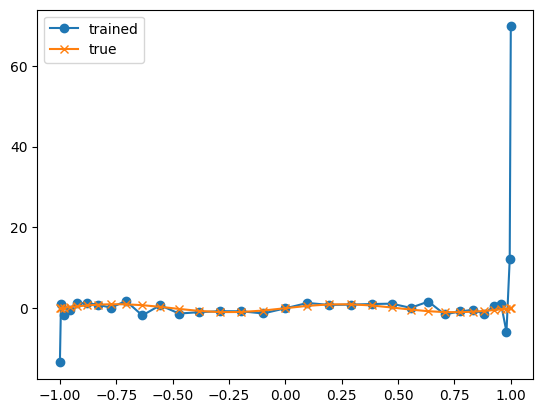

In [33]:
xs_cheb = cheb_lobatto_nodes(33)
plt.plot(xs_cheb, model.y, 'o-', label='trained')
plt.plot(xs_cheb, jnp.sin(2.0 * jnp.pi * 1 * xs_cheb), 'x-', label='true')
plt.legend()